[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.067271 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001729 -> initscore=-6.358339
[LightGBM] [Info] Start training from score -6.358339
[LightGBM] [Info] Number of positive: 55, number of negative: 28426
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000183 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 28481, number of used features: 1
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001931 -> initscore=-6.247726
[LightG

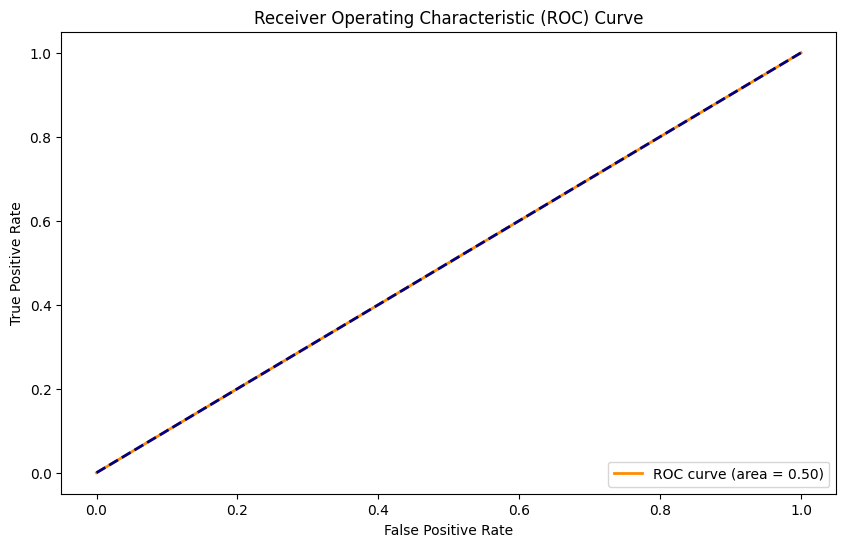

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('creditcard.csv')

# Separate features and target variable
X = df.drop('Class', axis=1)
y = df['Class']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train LightGBM model
lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict(X_test)

# Use LightGBM for meta-learning as well
meta_features = lgb_model.predict_proba(X_test)[:, 1].reshape(-1, 1)

# Split the training set further for the meta-learner
X_train_meta, X_val_meta, y_train_meta, y_val_meta = train_test_split(meta_features, y_test, test_size=0.5, random_state=42)

# Train LightGBM as the meta-learner
meta_learner = lgb.LGBMClassifier(random_state=42)
meta_learner.fit(X_train_meta, y_train_meta)

# Predict on the validation set
meta_pred = meta_learner.predict(X_val_meta)

# Evaluate the meta-learner
accuracy = accuracy_score(y_val_meta, meta_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')



fpr, tpr, _ = roc_curve(y_val_meta, meta_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()